# Performance Analysis (Sports)

This notebook loads Sports-only inference profiling artifacts for RPG graph decoding, exact chunked RPG brute-force scoring, and SASRec from both the shared group artifacts tree and repo-local artifacts. It summarizes the latest available profiling session for each method and creates merged scaling plots for candidate-pool size versus inference time, CUDA runtime memory, and NDCG@10.

Expected layouts:

```text
<artifact-root>/.../sports.../<session>/manifest.json
<artifact-root>/.../sports.../<session>/summaries/profile_summary.csv
<artifact-root>/.../sports.../<session>/graphs/validate_graph_report.json
```

RPG graph-validation reports are still shown when available. `RPG brute force` is the exact chunked no-graph scorer; chunking changes memory behavior, not the ranking objective.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import Markdown, display
except ImportError:
    class Markdown(str):
        pass

    def display(value):
        print(value)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

ROOT = Path.cwd().resolve()
while ROOT.name not in {"RPG", "RPG-uva"} and ROOT.parent != ROOT:
    ROOT = ROOT.parent

SPORTS_CATEGORY_ALIASES = {"sports_and_outdoors", "sports"}

ARTIFACT_SOURCES = [
    {"artifact_model": "RPG", "root": Path("/projects/prjs2120/groups/group_16/artifacts/rpg/perf")},
    {"artifact_model": "RPG", "root": ROOT / "artifacts" / "rpg" / "perf"},
    {"artifact_model": "SASRec", "root": Path("/projects/prjs2120/groups/group_16/artifacts/sasrec/perf")},
    {"artifact_model": "SASRec", "root": ROOT / "artifacts" / "sasrec" / "perf"},
    {"artifact_model": "SASRec", "root": Path("/projects/prjs2120/groups/group_16/artifacts/sasrec_modernized/perf")},
    {"artifact_model": "SASRec", "root": ROOT / "artifacts" / "sasrec_modernized" / "perf"},
]

METHOD_LABELS = {
    "RPG": "RPG graph",
    "RPG-BruteForce": "RPG brute force",
    "SASRec": "SASRec",
    "SASRec-ParamMatched": "SASRec param-matched",
    "SASRec graph": "SASRec graph (base ckpt)",
    "SASRec param-matched graph": "SASRec graph (param-matched ckpt)",
}
METHOD_ORDER = [
    "RPG graph",
    "RPG brute force",
    "SASRec",
    "SASRec param-matched",
    "SASRec graph (base ckpt)",
    "SASRec graph (param-matched ckpt)",
]
PLOT_COLORS = {
    "RPG graph": "#355C7D",
    "RPG brute force": "#C8553D",
    "SASRec": "#2A9D8F",
    "SASRec param-matched": "#E9C46A",
    "SASRec graph (base ckpt)": "#4F6D7A",
    "SASRec graph (param-matched ckpt)": "#BC6C25",
}
PLOT_MARKERS = {
    "RPG graph": "o",
    "RPG brute force": "s",
    "SASRec": "^",
    "SASRec param-matched": "D",
    "SASRec graph (base ckpt)": "P",
    "SASRec graph (param-matched ckpt)": "X",
}


In [2]:
def _read_json(path: Path):
    return json.loads(path.read_text())


def _safe_read_csv(path: Path) -> pd.DataFrame:
    if not path.is_file() or path.stat().st_size == 0:
        return pd.DataFrame()
    return pd.read_csv(path)


def _decorate_frame(frame: pd.DataFrame, **metadata) -> pd.DataFrame:
    if frame.empty:
        return frame
    result = frame.copy()
    for key, value in metadata.items():
        result[key] = value
    return result


def _method_label(method: str, artifact_model: str) -> str:
    if pd.isna(method):
        method = artifact_model
    return METHOD_LABELS.get(str(method), str(method))


def _series_label(method: str, artifact_model: str, session_root: Path) -> str:
    method = artifact_model if pd.isna(method) else str(method)
    session_parts = {_sports_token(part) for part in session_root.parts}
    if method == "SASRec" and "best_ablation" in session_parts:
        return METHOD_LABELS["SASRec-ParamMatched"]
    if method in METHOD_LABELS:
        return METHOD_LABELS[method]
    return _method_label(method, artifact_model)


def _sports_token(value) -> str:
    if value is None or pd.isna(value):
        return ""
    return str(value).strip().lower().replace("-", "_").replace(" ", "_")


def _path_looks_like_sports(path: Path) -> bool:
    parts = [_sports_token(part) for part in path.parts]
    return any(part in SPORTS_CATEGORY_ALIASES for part in parts)


def _frame_is_sports(frame: pd.DataFrame, fallback_path: Path) -> pd.Series:
    if frame.empty:
        return pd.Series(dtype=bool)
    mask = pd.Series(False, index=frame.index)
    for column in ("category", "dataset_slug", "preset", "dataset"):
        if column in frame.columns:
            mask = mask | frame[column].map(lambda value: _sports_token(value) in SPORTS_CATEGORY_ALIASES)
    if not mask.any() and _path_looks_like_sports(fallback_path):
        mask = pd.Series(True, index=frame.index)
    return mask


def _method_rank(value: str) -> int:
    return METHOD_ORDER.index(value) if value in METHOD_ORDER else len(METHOD_ORDER)


def _sort_existing(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    sort_columns = [column for column in columns if column in frame.columns]
    if not sort_columns:
        return frame.reset_index(drop=True)
    return frame.sort_values(sort_columns).reset_index(drop=True)


def load_perf_artifacts():
    manifest_rows = []
    summary_frames = []
    graph_frames = []
    validation_rows = []
    validation_graph_rows = []

    for source in ARTIFACT_SOURCES:
        artifact_root = source["root"]
        artifact_model = source["artifact_model"]
        if not artifact_root.exists():
            continue

        for manifest_path in sorted(artifact_root.rglob("manifest.json")):
            session_root = manifest_path.parent.resolve()
            if not _path_looks_like_sports(session_root):
                continue
            payload = _read_json(manifest_path)
            summary_path = session_root / "summaries" / "profile_summary.csv"
            raw_path = session_root / "raw" / "profile_runs.csv"
            graph_path = session_root / "graphs" / "graph_builds.csv"

            manifest_rows.append(
                {
                    "artifact_model": artifact_model,
                    "artifact_root": str(artifact_root),
                    "session": session_root.name,
                    "session_root": str(session_root),
                    "manifest_path": str(manifest_path),
                    "summary_path": str(summary_path),
                    "raw_path": str(raw_path),
                    "graph_path": str(graph_path),
                    "has_summary_csv": summary_path.is_file(),
                    "has_raw_csv": raw_path.is_file(),
                    "has_graph_csv": graph_path.is_file(),
                }
            )

            summary_df = _safe_read_csv(summary_path)
            if not summary_df.empty:
                summary_df = summary_df.loc[_frame_is_sports(summary_df, session_root)].copy()
            if not summary_df.empty:
                summary_df = summary_df.copy()
                if "method" not in summary_df.columns:
                    summary_df["method"] = artifact_model
                summary_df["artifact_model"] = artifact_model
                summary_df["model"] = [
                    _series_label(method, artifact_model, session_root) for method in summary_df["method"]
                ]

            summary_frames.append(
                _decorate_frame(
                    summary_df,
                    artifact_root=str(artifact_root),
                    session=session_root.name,
                    session_root=str(session_root),
                    manifest_path=str(manifest_path),
                    summary_path=str(summary_path),
                    raw_path=str(raw_path),
                    graph_path=str(graph_path),
                )
            )

            graph_df = _safe_read_csv(graph_path)
            if not graph_df.empty:
                graph_df = graph_df.loc[_frame_is_sports(graph_df, session_root)].copy()
            graph_frames.append(
                _decorate_frame(
                    graph_df,
                    artifact_model=artifact_model,
                    model=_method_label(artifact_model, artifact_model),
                    artifact_root=str(artifact_root),
                    session=session_root.name,
                    session_root=str(session_root),
                    manifest_path=str(manifest_path),
                    graph_path=str(graph_path),
                )
            )

        if artifact_model != "RPG":
            continue
        for report_path in sorted(artifact_root.rglob("validate_graph_report.json")):
            if not _path_looks_like_sports(report_path):
                continue
            session_root = report_path.parents[1].resolve()
            payload = _read_json(report_path)
            comparisons = payload.get("comparisons", {})
            validation_rows.append(
                {
                    "artifact_model": artifact_model,
                    "model": "RPG graph",
                    "artifact_root": str(artifact_root),
                    "session": session_root.name,
                    "session_root": str(session_root),
                    "report_path": str(report_path),
                    "paper_md_path": str(report_path.with_name("paper.md")),
                    "checkpoint_path": payload.get("checkpoint_path"),
                    "checkpoint_name": None if payload.get("checkpoint_path") is None else Path(payload["checkpoint_path"]).name,
                    "checkpoint_signature": payload.get("checkpoint_signature"),
                    "pool_size": payload.get("pool_size"),
                    "topk": payload.get("topk"),
                    "dense_vs_flat_mean_overlap": comparisons.get("dense_vs_flat", {}).get("mean_overlap_rate"),
                    "dense_vs_flat_exact_match_rate": comparisons.get("dense_vs_flat", {}).get("exact_match_rate"),
                    "flat_vs_hnsw_mean_overlap": comparisons.get("flat_vs_hnsw", {}).get("mean_overlap_rate"),
                    "flat_vs_hnsw_p50_overlap": comparisons.get("flat_vs_hnsw", {}).get("p50_overlap_rate"),
                    "dense_vs_hnsw_mean_overlap": comparisons.get("dense_vs_hnsw", {}).get("mean_overlap_rate"),
                    "dense_vs_hnsw_p50_overlap": comparisons.get("dense_vs_hnsw", {}).get("p50_overlap_rate"),
                }
            )
            for graph_record in payload.get("graph_records", []):
                validation_graph_rows.append(
                    {
                        "artifact_model": artifact_model,
                        "model": "RPG graph",
                        "artifact_root": str(artifact_root),
                        "session": session_root.name,
                        "session_root": str(session_root),
                        "report_path": str(report_path),
                        **graph_record,
                    }
                )

    manifest_index = pd.DataFrame(manifest_rows)
    if not manifest_index.empty:
        manifest_index = _sort_existing(manifest_index, ["artifact_model", "session", "artifact_root"])
    profile_summaries = pd.concat([frame for frame in summary_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in summary_frames) else pd.DataFrame()
    if not profile_summaries.empty:
        profile_summaries = profile_summaries.assign(method_rank=profile_summaries["model"].map(_method_rank))
        profile_summaries = _sort_existing(profile_summaries, ["method_rank", "session", "pool_size", "artifact_root"])
    graph_builds = pd.concat([frame for frame in graph_frames if not frame.empty], ignore_index=True) if any(not frame.empty for frame in graph_frames) else pd.DataFrame()
    if not graph_builds.empty:
        graph_builds = graph_builds.assign(method_rank=graph_builds["model"].map(_method_rank))
        graph_builds = _sort_existing(graph_builds, ["method_rank", "session", "pool_size", "artifact_root"])
    validation_runs = pd.DataFrame(validation_rows)
    if not validation_runs.empty:
        validation_runs = _sort_existing(validation_runs, ["session", "artifact_root"])
    validation_graphs = pd.DataFrame(validation_graph_rows)
    if not validation_graphs.empty:
        validation_graphs = _sort_existing(validation_graphs, ["session", "pool_size", "graph_backend"])
    return manifest_index, profile_summaries, graph_builds, validation_runs, validation_graphs


In [3]:
manifest_index, profile_summaries, graph_builds, validation_runs, validation_graphs = load_perf_artifacts()

existing_roots = [f"{source['artifact_model']}: {source['root']}" for source in ARTIFACT_SOURCES if source["root"].exists()]
print(
    f"Discovered {len(manifest_index)} profiling sessions and {len(validation_runs)} validation reports across {len(existing_roots)} artifact roots."
)
if existing_roots:
    print("Existing artifact roots:")
    for root in existing_roots:
        print(f"  - {root}")

if manifest_index.empty:
    print("No manifest.json files found under the configured perf artifact roots.")
else:
    display(
        manifest_index[
            [
                "artifact_model",
                "session",
                "artifact_root",
                "has_summary_csv",
                "has_raw_csv",
                "has_graph_csv",
                "summary_path",
            ]
        ].sort_values(["artifact_model", "session", "artifact_root"], ascending=[True, False, True]).reset_index(drop=True)
    )


Discovered 10 profiling sessions and 1 validation reports across 2 artifact roots.
Existing artifact roots:
  - RPG: /gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf
  - SASRec: /gpfs/home6/scur0291/RPG-uva/artifacts/sasrec_modernized/perf


,artifact_model,session,artifact_root,has_summary_csv,has_raw_csv,has_graph_csv,summary_path
0,RPG,20260619T102453985310Z_job24019933,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,True,True,False,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...
1,RPG,20260619T102219472190Z_job24019933,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,True,True,False,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...
2,RPG,20260619T101931360055Z_job24019933,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,True,True,False,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...
3,RPG,20260619T101635233401Z_job24019933,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,True,True,False,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...
4,RPG,20260619T090343870627Z_job24018539,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,True,True,False,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...
5,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,True,True,True,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...
6,SASRec,20260622T122012Z_job24103694,/gpfs/home6/scur0291/RPG-uva/artifacts/sasrec_...,False,False,False,/gpfs/home6/scur0291/RPG-uva/artifacts/sasrec_...
7,SASRec,20260622T120914298067Z_job24103694,/gpfs/home6/scur0291/RPG-uva/artifacts/sasrec_...,True,True,False,/gpfs/home6/scur0291/RPG-uva/artifacts/sasrec_...
8,SASRec,20260622T115830309073Z_job24103694,/gpfs/home6/scur0291/RPG-uva/artifacts/sasrec_...,True,True,False,/gpfs/home6/scur0291/RPG-uva/artifacts/sasrec_...
9,SASRec,20260620T171417056731Z_job24052735,/gpfs/home6/scur0291/RPG-uva/artifacts/sasrec_...,True,True,False,/gpfs/home6/scur0291/RPG-uva/artifacts/sasrec_...


## Latest Profiling Sessions

This table keeps the latest discovered profiling session per method and shows the per-pool median latency, CUDA memory, traversal, and `NDCG@10` measurements. The SASRec graph curves are split into `base ckpt` and `param-matched ckpt` so you can compare them directly against the non-graph baselines.


In [4]:
if profile_summaries.empty:
    print("No profile summary rows available.")
    latest_profile_rows = pd.DataFrame()
else:
    session_candidates = (
        profile_summaries.groupby(
            ["model", "artifact_root", "session", "session_root", "method_rank"],
            as_index=False,
        )
        .agg(n_pool_sizes=("pool_size", "nunique"), max_pool_size=("pool_size", "max"))
    )
    latest_sessions = (
        session_candidates
        .sort_values(["method_rank", "n_pool_sizes", "max_pool_size", "session", "artifact_root"])
        .groupby("model", as_index=False)
        .tail(1)
    )
    latest_profile_rows = profile_summaries.merge(
        latest_sessions[["model", "session_root"]],
        on=["model", "session_root"],
        how="inner",
    ).sort_values(["method_rank", "pool_size"]).reset_index(drop=True)

    display_columns = [
        "model",
        "method",
        "session",
        "artifact_root",
        "pool_size",
        "graph_backend",
        "epoch_time_s_median",
        "peak_cuda_runtime_delta_allocated_gb_median",
        "peak_cuda_allocated_gb_median",
        "visited_ratio_median",
        "n_visited_items_median",
        "ndcg_at_10_median",
        "recall_at_10_median",
        "checkpoint_signature",
    ]
    existing_columns = [column for column in display_columns if column in latest_profile_rows.columns]
    display(
        latest_profile_rows[existing_columns].style.format(
            {
                "epoch_time_s_median": "{:.2f}",
                "peak_cuda_runtime_delta_allocated_gb_median": "{:.3f}",
                "peak_cuda_allocated_gb_median": "{:.3f}",
                "visited_ratio_median": "{:.4f}",
                "n_visited_items_median": "{:.1f}",
                "ndcg_at_10_median": "{:.5f}",
                "recall_at_10_median": "{:.5f}",
            }
        )
    )

    if not graph_builds.empty:
        latest_graph_rows = graph_builds.merge(
            latest_sessions[["model", "session_root"]],
            on=["model", "session_root"],
            how="inner",
        ).sort_values(["method_rank", "pool_size"]).reset_index(drop=True)
        if not latest_graph_rows.empty:
            display(Markdown("### RPG graph-build rows"))
            display(latest_graph_rows)


,model,method,session,artifact_root,pool_size,graph_backend,epoch_time_s_median,peak_cuda_runtime_delta_allocated_gb_median,peak_cuda_allocated_gb_median,visited_ratio_median,n_visited_items_median,ndcg_at_10_median,recall_at_10_median,checkpoint_signature
0,RPG graph,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,20000,hnsw,37.23,0.103,0.197,0.0798,1595.8,0.01755,nan,783be92f6501
1,RPG graph,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,50000,hnsw,36.30,0.104,0.221,0.0256,1277.6,0.00564,nan,783be92f6501
2,RPG graph,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,100000,hnsw,34.46,0.103,0.265,0.0113,1132.7,0.00173,nan,783be92f6501
3,RPG graph,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,200000,hnsw,34.34,0.104,0.352,0.0053,1066.9,0.00049,nan,783be92f6501
4,RPG graph,RPG,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,500000,hnsw,33.64,0.104,0.612,0.0021,1040.3,0.00014,nan,783be92f6501
5,RPG brute force,RPG-BruteForce,20260619T090343870627Z_job24018539,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,20000,full_sort_chunked,13.04,0.153,0.195,1.0000,20000.0,0.02370,0.04149,783be92f6501
6,RPG brute force,RPG-BruteForce,20260619T090343870627Z_job24018539,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,50000,full_sort_chunked,13.72,0.384,0.429,1.0000,50000.0,0.01446,0.02756,783be92f6501
7,RPG brute force,RPG-BruteForce,20260619T090343870627Z_job24018539,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,100000,full_sort_chunked,15.09,0.390,0.442,1.0000,100000.0,0.01195,0.01775,783be92f6501
8,RPG brute force,RPG-BruteForce,20260619T090343870627Z_job24018539,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,200000,full_sort_chunked,17.71,0.391,0.454,1.0000,200000.0,0.00540,0.01185,783be92f6501
9,RPG brute force,RPG-BruteForce,20260619T090343870627Z_job24018539,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,500000,full_sort_chunked,25.75,0.393,0.493,1.0000,500000.0,0.01014,0.01185,783be92f6501


### RPG graph-build rows

,cache_id,adjacency_path,metadata_path,backend,pool_size,topk,vector_batch_size,build_seconds,loaded_from_cache,checkpoint_signature,artifact_model,model,artifact_root,session,session_root,manifest_path,graph_path,method_rank
0,rpg_sports_and_outdoors_pool20000_backend-hnsw...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,20000,100,512,84.085703,True,783be92f6501,RPG,RPG graph,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,0
1,rpg_sports_and_outdoors_pool50000_backend-hnsw...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,50000,100,512,288.902416,True,783be92f6501,RPG,RPG graph,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,0
2,rpg_sports_and_outdoors_pool100000_backend-hns...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,100000,100,512,509.885182,True,783be92f6501,RPG,RPG graph,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,0
3,rpg_sports_and_outdoors_pool200000_backend-hns...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,200000,100,512,932.074320,True,783be92f6501,RPG,RPG graph,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,0
4,rpg_sports_and_outdoors_pool500000_backend-hns...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,500000,100,512,1668.942545,True,783be92f6501,RPG,RPG graph,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/perf,20260605T193847131557Z_job23505191,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,/gpfs/home6/scur0291/RPG-uva/artifacts/rpg/per...,0


## Merged Paper-Style Scaling Plots

These plots compare the latest Sports profiling sessions for RPG graph decoding, exact chunked RPG brute force, standard SASRec, and parameter-matched SASRec. Runtime CUDA delta subtracts the already-loaded model/graph/embedding baseline, so it is the most useful memory metric for comparing inference work rather than checkpoint size.


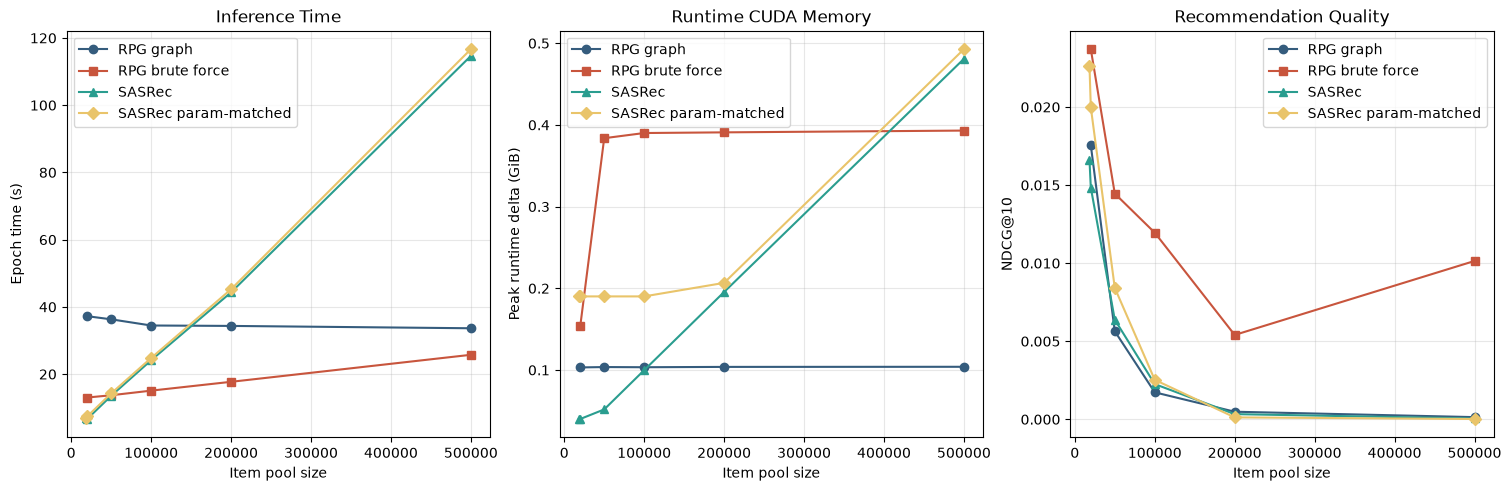

### 500,000-item snapshot

,model,pool_size,epoch_time_s_median,peak_cuda_runtime_delta_allocated_gb_median,n_visited_items_median,visited_ratio_median,ndcg_at_10_median,recall_at_10_median
4,RPG graph,500000,33.64,0.104,1040.3,0.0021,0.00014,nan
9,RPG brute force,500000,25.75,0.393,500000.0,1.0000,0.01014,0.01185
15,SASRec,500000,114.66,0.481,500000.0,1.0000,0.00005,nan
21,SASRec param-matched,500000,116.67,0.493,500000.0,1.0000,0.00002,nan


In [5]:
if profile_summaries.empty or latest_profile_rows.empty:
    print("No profiling rows available for plotting.")
else:
    plot_rows = latest_profile_rows.sort_values(["method_rank", "pool_size"])
    plot_rows = plot_rows.loc[plot_rows["pool_size"] >= 20_000].copy()
    merged_rows = plot_rows.groupby("model", sort=False).filter(lambda frame: len(frame) > 1).copy()
    skipped_models = [
        model for model, frame in plot_rows.groupby("model", sort=False)
        if len(frame) <= 1
    ]

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True)
    handles = []
    labels = []

    x_ticks = sorted(merged_rows["pool_size"].dropna().unique()) if not merged_rows.empty else []
    x_positions = {value: idx for idx, value in enumerate(x_ticks)}
    tick_labels = [f"{int(value / 1000)}k" if value >= 1000 else f"{int(value)}" for value in x_ticks]

    for model, frame in merged_rows.groupby("model", sort=False):
        frame = frame.sort_values("pool_size")
        color = PLOT_COLORS.get(model)
        marker = PLOT_MARKERS.get(model, "o")
        x_values = [x_positions[value] for value in frame["pool_size"]]
        line_kwargs = {
            "marker": marker,
            "markersize": 6,
            "linewidth": 2,
            "label": model,
            "color": color,
        }
        line, = axes[0].plot(x_values, frame["epoch_time_s_median"], **line_kwargs)
        axes[1].plot(
            x_values,
            frame["peak_cuda_runtime_delta_allocated_gb_median"],
            **line_kwargs,
        )
        handles.append(line)
        labels.append(model)

    axes[0].set_title("Inference Time")
    axes[0].set_ylabel("Epoch time (s)")
    axes[1].set_title("Runtime CUDA Memory")
    axes[1].set_ylabel("Peak runtime delta (GiB)")

    for axis in axes:
        axis.set_xlabel("Item pool size")
        if x_ticks:
            axis.set_xticks(range(len(x_ticks)))
            axis.set_xticklabels(tick_labels, rotation=0)
        axis.grid(True, axis="y", alpha=0.28)
        axis.grid(True, axis="x", alpha=0.10)

    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=min(len(labels), 3), frameon=False, bbox_to_anchor=(0.5, 1.04))
    fig.tight_layout(rect=(0, 0, 1, 0.9))
    plt.show()

    if skipped_models:
        print(
            "Merged scaling plot skipped singleton or sub-20k series "
            f"({', '.join(skipped_models)}); see the dedicated brute-force comparison below."
        )

    max_pool = latest_profile_rows["pool_size"].max()
    snapshot_columns = [
        "model",
        "pool_size",
        "epoch_time_s_median",
        "peak_cuda_runtime_delta_allocated_gb_median",
        "n_visited_items_median",
        "visited_ratio_median",
        "ndcg_at_10_median",
        "recall_at_10_median",
    ]
    snapshot_columns = [column for column in snapshot_columns if column in latest_profile_rows.columns]
    display(Markdown(f"### {int(max_pool):,}-item snapshot"))
    display(
        latest_profile_rows.loc[latest_profile_rows["pool_size"] == max_pool, snapshot_columns]
        .sort_values("model", key=lambda series: series.map(_method_rank))
        .style.format(
            {
                "epoch_time_s_median": "{:.2f}",
                "peak_cuda_runtime_delta_allocated_gb_median": "{:.3f}",
                "n_visited_items_median": "{:.1f}",
                "visited_ratio_median": "{:.4f}",
                "ndcg_at_10_median": "{:.5f}",
                "recall_at_10_median": "{:.5f}",
            }
        )
    )



## 500k Sweet Spot Plot: Brute Force vs RPG Graph

This is the plot to use for the 500k memory/time tradeoff. Each square is exact RPG brute force with a different item chunk size; the star and dashed lines are the RPG graph 500k reference. Lower-left is better. The highlighted point is the fastest brute-force chunk whose runtime CUDA memory is no higher than the RPG graph reference, up to a small 5% tolerance.


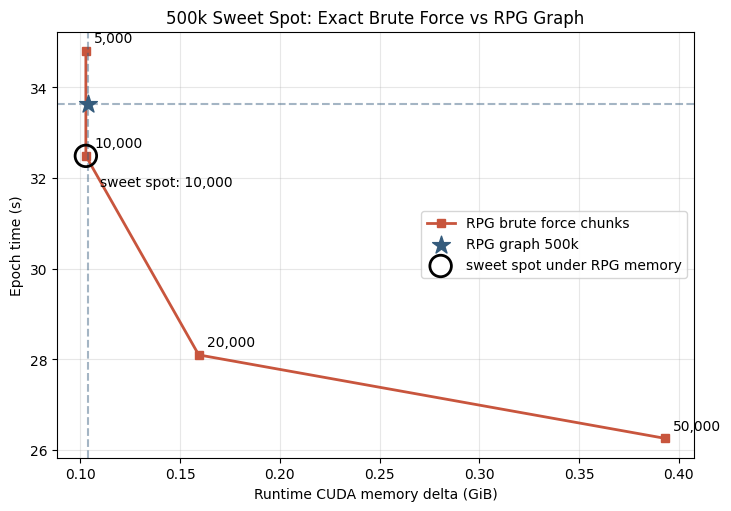

### 500k sweet-spot comparison table

,method,config,session,epoch_time_s_median,peak_cuda_runtime_delta_allocated_gb_median,peak_cuda_allocated_gb_median,ndcg_at_10_median,recall_at_10_median
1,RPG brute force,"chunk=10,000",20260619T101931360055Z_job24019933,32.49,0.103,0.203,0.00451,0.01185
0,RPG brute force,"chunk=5,000",20260619T101635233401Z_job24019933,34.80,0.103,0.203,0.00616,0.01185
4,RPG graph,graph decoding,20260605T193847131557Z_job23505191,33.64,0.104,0.612,0.00014,nan
2,RPG brute force,"chunk=20,000",20260619T102219472190Z_job24019933,28.10,0.159,0.260,0.00532,0.01185
3,RPG brute force,"chunk=50,000",20260619T102453985310Z_job24019933,26.26,0.393,0.493,0.01014,0.01185


In [19]:
if profile_summaries.empty or "bruteforce_item_chunk_size" not in profile_summaries.columns:
    print("No brute-force chunk-size rows available yet.")
else:
    chunk_rows = profile_summaries.loc[
        profile_summaries["model"].eq("RPG brute force")
        & profile_summaries["pool_size"].eq(500_000)
        & profile_summaries["bruteforce_item_chunk_size"].notna()
    ].copy()

    if chunk_rows.empty:
        print("No 500k brute-force chunk-size rows available yet.")
    else:
        chunk_rows["bruteforce_item_chunk_size"] = chunk_rows["bruteforce_item_chunk_size"].astype(int)
        chunk_latest = (
            chunk_rows.sort_values(["bruteforce_item_chunk_size", "session", "artifact_root"])
            .groupby("bruteforce_item_chunk_size", as_index=False)
            .tail(1)
            .sort_values("bruteforce_item_chunk_size")
            .reset_index(drop=True)
        )

        x_col = "peak_cuda_runtime_delta_allocated_gb_median"
        y_col = "epoch_time_s_median"
        graph_ref = latest_profile_rows.loc[
            latest_profile_rows["model"].eq("RPG graph") & latest_profile_rows["pool_size"].eq(500_000)
        ]
        graph_row = None if graph_ref.empty else graph_ref.sort_values("session").tail(1).iloc[0]

        fig, ax = plt.subplots(1, 1, figsize=(7.2, 5.0), constrained_layout=True)
        ax.plot(
            chunk_latest[x_col],
            chunk_latest[y_col],
            marker="s",
            linewidth=2,
            color=PLOT_COLORS["RPG brute force"],
            label="RPG brute force chunks",
        )
        for _, row in chunk_latest.iterrows():
            label = f"{int(row['bruteforce_item_chunk_size']):,}"
            ax.annotate(label, (row[x_col], row[y_col]), xytext=(6, 6), textcoords="offset points")

        if graph_row is not None:
            ax.scatter(
                [graph_row[x_col]],
                [graph_row[y_col]],
                marker="*",
                s=180,
                color=PLOT_COLORS["RPG graph"],
                label="RPG graph 500k",
                zorder=4,
            )
            ax.axvline(graph_row[x_col], color=PLOT_COLORS["RPG graph"], linestyle="--", alpha=0.45)
            ax.axhline(graph_row[y_col], color=PLOT_COLORS["RPG graph"], linestyle="--", alpha=0.45)

            memory_budget = graph_row[x_col] * 1.05
            feasible = chunk_latest.loc[chunk_latest[x_col] <= memory_budget]
            if not feasible.empty:
                sweet_spot = feasible.sort_values(y_col).iloc[0]
                ax.scatter(
                    [sweet_spot[x_col]],
                    [sweet_spot[y_col]],
                    marker="o",
                    s=240,
                    facecolors="none",
                    edgecolors="black",
                    linewidths=2,
                    label="sweet spot under RPG memory",
                    zorder=5,
                )
                ax.annotate(
                    f"sweet spot: {int(sweet_spot['bruteforce_item_chunk_size']):,}",
                    (sweet_spot[x_col], sweet_spot[y_col]),
                    xytext=(10, -22),
                    textcoords="offset points",
                )

        ax.set_title("500k Sweet Spot: Exact Brute Force vs RPG Graph")
        ax.set_xlabel("Runtime CUDA memory delta (GiB)")
        ax.set_ylabel("Epoch time (s)")
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.show()

        table_columns = [
            "method",
            "config",
            "session",
            "epoch_time_s_median",
            "peak_cuda_runtime_delta_allocated_gb_median",
            "peak_cuda_allocated_gb_median",
            "ndcg_at_10_median",
            "recall_at_10_median",
        ]
        comparison_rows = chunk_latest.assign(
            method="RPG brute force",
            config=chunk_latest["bruteforce_item_chunk_size"].map(lambda value: f"chunk={int(value):,}"),
        )
        if graph_row is not None:
            graph_table_row = pd.DataFrame(
                [
                    {
                        "method": "RPG graph",
                        "config": "graph decoding",
                        "session": graph_row["session"],
                        "epoch_time_s_median": graph_row[y_col],
                        "peak_cuda_runtime_delta_allocated_gb_median": graph_row[x_col],
                        "peak_cuda_allocated_gb_median": graph_row.get("peak_cuda_allocated_gb_median", float("nan")),
                        "ndcg_at_10_median": graph_row.get("ndcg_at_10_median", float("nan")),
                        "recall_at_10_median": graph_row.get("recall_at_10_median", float("nan")),
                    }
                ]
            )
            comparison_rows = pd.concat([comparison_rows, graph_table_row], ignore_index=True, sort=False)

        display(Markdown("### 500k sweet-spot comparison table"))
        display(
            comparison_rows[table_columns].sort_values(
                ["peak_cuda_runtime_delta_allocated_gb_median", "epoch_time_s_median"]
            ).style.format(
                {
                    "epoch_time_s_median": "{:.2f}",
                    "peak_cuda_runtime_delta_allocated_gb_median": "{:.3f}",
                    "peak_cuda_allocated_gb_median": "{:.3f}",
                    "ndcg_at_10_median": "{:.5f}",
                    "recall_at_10_median": "{:.5f}",
                }
            )
        )


## Latest RPG Graph-Validation Report

If an RPG `validate_graph_report.json` session exists, this section shows the latest overlap summary plus the paper-ready text snippet written by the validation job.


In [20]:
if validation_runs.empty:
    print("No RPG validate_graph_report.json files found.")
else:
    latest_validation = (
        validation_runs.sort_values(["session", "artifact_root"])
        .tail(1)
        .reset_index(drop=True)
    )
    display(
        latest_validation[
            [
                "session",
                "artifact_root",
                "pool_size",
                "topk",
                "checkpoint_signature",
                "dense_vs_flat_mean_overlap",
                "dense_vs_flat_exact_match_rate",
                "flat_vs_hnsw_mean_overlap",
                "flat_vs_hnsw_p50_overlap",
                "dense_vs_hnsw_mean_overlap",
                "dense_vs_hnsw_p50_overlap",
            ]
        ].style.format(
            {
                "dense_vs_flat_mean_overlap": "{:.4%}",
                "dense_vs_flat_exact_match_rate": "{:.4%}",
                "flat_vs_hnsw_mean_overlap": "{:.4%}",
                "flat_vs_hnsw_p50_overlap": "{:.2%}",
                "dense_vs_hnsw_mean_overlap": "{:.4%}",
                "dense_vs_hnsw_p50_overlap": "{:.2%}",
            }
        )
    )

    latest_validation_row = latest_validation.iloc[0]
    latest_validation_graphs = (
        validation_graphs[validation_graphs["session_root"] == latest_validation_row["session_root"]]
        .sort_values("backend")
        .reset_index(drop=True)
    )
    if not latest_validation_graphs.empty:
        display(latest_validation_graphs)

    paper_md_path = Path(latest_validation_row["paper_md_path"])
    if paper_md_path.is_file():
        display(Markdown("### Paper-ready summary"))
        display(Markdown(paper_md_path.read_text()))


,session,artifact_root,pool_size,topk,checkpoint_signature,dense_vs_flat_mean_overlap,dense_vs_flat_exact_match_rate,flat_vs_hnsw_mean_overlap,flat_vs_hnsw_p50_overlap,dense_vs_hnsw_mean_overlap,dense_vs_hnsw_p50_overlap
0,20260606T085403711257Z_job23517619,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sports,18357,100,783be92f6501,99.9910%,99.2373%,98.9475%,99.00%,98.9503%,99.00%


,artifact_model,model,artifact_root,session,session_root,report_path,backend,pool_size,topk,build_seconds,cached,graph_hnsw_m,graph_hnsw_ef_construction,graph_hnsw_ef_search
0,RPG,RPG graph,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,20260606T085403711257Z_job23517619,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,flat,18357,100,68.776752,False,NaN,NaN,NaN
1,RPG,RPG graph,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,20260606T085403711257Z_job23517619,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,/gpfs/home6/scur1202/RPG/artifacts/rpg/perf/sp...,hnsw,18357,100,105.522489,False,32.0,200.0,256.0


### Paper-ready summary

To validate the scalable graph construction backend, we measured the top-100 neighbor overlap between alternative graph builders on the original Sports item pool. For each item, overlap is defined as the fraction of neighbors shared between the two top-100 neighbor sets. This metric is less brittle than exact list equality, since small numerical differences or near-ties at the boundary of the top-100 can change one or two neighbors without materially changing the graph structure. The exact FAISS flat backend reproduced the upstream dense graph with a mean top-100 overlap of 99.99%, confirming that our repo-owned exact implementation is faithful to the original graph construction. The HNSW backend, used for scalable enlarged-pool profiling, achieved 98.95% mean top-100 overlap against the exact FAISS flat graph, with median overlap 99% and 5th-percentile overlap 97%. These results indicate that HNSW provides a high-fidelity approximation of the exact item graph while enabling graph construction at larger pool sizes required for the Figure 3 efficiency study.